In [1]:
!pip install ultralytics opencv-python numpy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import time
from collections import defaultdict, deque

import cv2
import numpy as np
from ultralytics import YOLO

In [3]:
VIDEO_PATH = "video.mp4" 
OUTPUT_VIDEO_PATH = "output_1.mp4"
OUTPUT_HEATMAP_PATH = "heatmap.png"

MODEL_PATH = "yolov8n.pt" 
PERSON_CLASS_ID = 0

# Проверка наличия видео
if not os.path.exists(VIDEO_PATH):
    print(f"Файл {VIDEO_PATH} не найден!")
    print("Скачайте видео или положите файл в папку с ноутбуком.")
else:
    print(f"Видео найдено: {VIDEO_PATH}")

Видео найдено: video.mp4


In [4]:
model = YOLO(MODEL_PATH)
print(" Модель YOLO загружена")

 Модель YOLO загружена


In [5]:
# Инициализация счётчиков и структур данных
track_history = defaultdict(list)
counted_ids_in = set()
counted_ids_out = set()
total_in = 0
total_out = 0
line_margin = 10

In [6]:
def get_box_center(x1, y1, x2, y2):
    """Вычисляет центр бокса"""
    cx = int((x1 + x2) / 2)
    cy = int((y1 + y2) / 2)
    return cx, cy

def draw_line(frame, y):
    """Рисует линию подсчёта на кадре"""
    h, w = frame.shape[:2]
    cv2.line(frame, (0, y), (w, y), (0, 255, 255), 2)
    cv2.putText(frame, "COUNT LINE", (10, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)

def estimate_density(num_people, frame_area):
    """Оценивает плотность людей"""
    return num_people / frame_area

def density_label(density):
    """Возвращает текстовую метку плотности"""
    if density < 0.00002:
        return "Low"
    elif density < 0.00005:
        return "Medium"
    else:
        return "High"
    
    # Ячейка инициализации видео
cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    raise ValueError("Не удалось открыть видео")

fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

line_y = height // 2
frame_area = width * height

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(OUTPUT_VIDEO_PATH, fourcc, fps, (width, height))

heatmap_accumulator = np.zeros((height, width), dtype=np.float32)

print(f"Видео: {width}x{height}, FPS={fps}")
print(f"Линия подсчёта: y = {line_y}")

Видео: 898x506, FPS=25
Линия подсчёта: y = 253


In [7]:
!pip install tqdm


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
# ОБРАБОТКА ВИДЕО
from tqdm import tqdm  # Для красоты
import time

def process_frame(frame, model, track_history, counted_ids_in, counted_ids_out, 
                  total_in, total_out, heatmap_accumulator, line_y, 
                  width, height, frame_area, PERSON_CLASS_ID):
   
    results = model.track(
        source=frame,
        persist=True,
        classes=[PERSON_CLASS_ID],
        tracker="bytetrack.yaml",
        conf=0.35,
        verbose=False
    )
    
    annotated_frame = frame.copy()
    current_people = 0
    
    # Проверка на наличие детекций
    if results[0].boxes is not None and results[0].boxes.id is not None:
        boxes = results[0].boxes.xyxy.cpu().numpy()
        track_ids = results[0].boxes.id.cpu().numpy().astype(int)
        classes = results[0].boxes.cls.cpu().numpy().astype(int)
        confs = results[0].boxes.conf.cpu().numpy()
        
        for box, track_id, cls_id, conf in zip(boxes, track_ids, classes, confs):
            if cls_id != PERSON_CLASS_ID:
                continue
            current_people += 1
            
            x1, y1, x2, y2 = map(int, box)
            cx, cy = get_box_center(x1, y1, x2, y2)
            
            # Обновление истории трека
            track_history[track_id].append((cx, cy))
            if len(track_history[track_id]) > 30:
                track_history[track_id].pop(0)
            
            # Детекция пересечения линии
            if len(track_history[track_id]) >= 2:
                prev_cx, prev_cy = track_history[track_id][-2]
                
                if prev_cy < line_y <= cy and track_id not in counted_ids_in:
                    total_in += 1
                    counted_ids_in.add(track_id)
                    print(f"Человек вошёл (ID: {track_id})")
                
                elif prev_cy > line_y >= cy and track_id not in counted_ids_out:
                    total_out += 1
                    counted_ids_out.add(track_id)
                    print(f"Человек вышел (ID: {track_id})")
            
            radius = 20
            x_min, x_max = max(cx - radius, 0), min(cx + radius, width)
            y_min, y_max = max(cy - radius, 0), min(cy + radius, height)
            heatmap_accumulator[y_min:y_max, x_min:x_max] += 1
            
            # Визуализация
            cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.circle(annotated_frame, (cx, cy), 4, (0, 0, 255), -1)
            cv2.putText(annotated_frame, f"ID {track_id} | {conf:.2f}",
                       (x1, max(y1 - 10, 20)), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
            
            # Рисуем траекторию
            points = track_history[track_id]
            for i in range(1, len(points)):
                cv2.line(annotated_frame, points[i-1], points[i], (255, 0, 0), 2)
    
    density = estimate_density(current_people, frame_area)
    draw_line(annotated_frame, line_y)
    
    # Инфо-панель
    y_offset = 30
    for text, color in [
        (f"Current: {current_people}", (255, 255, 255)),
        (f"IN: {total_in}", (0, 255, 0)),
        (f"OUT: {total_out}", (0, 165, 255)),
        (f"Density: {density:.6f} ({density_label(density)})", (255, 255, 0))
    ]:
        cv2.putText(annotated_frame, text, (10, y_offset), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
        y_offset += 35
    
    return annotated_frame, track_history, counted_ids_in, counted_ids_out, total_in, total_out, heatmap_accumulator


print("Запуск обработки видео...")
start_time = time.time()
frame_idx = 0
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Прогресс-бар
pbar = tqdm(total=total_frames, desc="Обработка кадров", unit="кадр")

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    frame_idx += 1
    
    annotated_frame, track_history, counted_ids_in, counted_ids_out, total_in, total_out, heatmap_accumulator = \
        process_frame(
            frame, model, track_history, counted_ids_in, counted_ids_out,
            total_in, total_out, heatmap_accumulator, line_y,
            width, height, frame_area, PERSON_CLASS_ID
        )
    
    # Запись кадра
    out.write(annotated_frame)
    
    # Обновление прогресс-бара
    pbar.update(1)
    

pbar.close()
cap.release()
out.release()
cv2.destroyAllWindows()

# ИТОГИ
end_time = time.time()
processing_time = end_time - start_time
fps_processed = frame_idx / processing_time if processing_time > 0 else 0

print("\n" + "="*50)
print("ОБРАБОТКА ЗАВЕРШЕНА")
print(f" Всего кадров: {frame_idx}")
print(f"Время обработки: {processing_time:.2f} сек")
print(f"FPS обработки: {fps_processed:.2f}")
print(f"Вошло людей: {total_in}")
print(f"Вышло людей: {total_out}")
print(f"Баланс: {total_in - total_out}")

Запуск обработки видео...


Обработка кадров:  21%|██        | 127/618 [00:20<01:03,  7.74кадр/s]

Человек вышел (ID: 2)


Обработка кадров:  26%|██▋       | 163/618 [00:25<01:05,  6.98кадр/s]

Человек вышел (ID: 1)


...

Человек вышел (ID: 55)


Обработка кадров:  96%|█████████▌| 593/618 [01:42<00:06,  3.92кадр/s]

Человек вышел (ID: 69)


Обработка кадров: 100%|██████████| 618/618 [01:47<00:00,  5.73кадр/s]


ОБРАБОТКА ЗАВЕРШЕНА
 Всего кадров: 618
Время обработки: 107.95 сек
FPS обработки: 5.73
Вошло людей: 4
Вышло людей: 30
Баланс: -26


Отрицательный баланс нормален, потому что скрипт считает пересечения линии. Если в начале видео люди уже находились в кадре (ниже линии), а потом ушли — они записались в «Вышедших», но не в «Вошедших». Чтобы баланс был нулевым, нужно снимать видео с пустой сцены, чтобы все люди заходили в кадр с нуля.

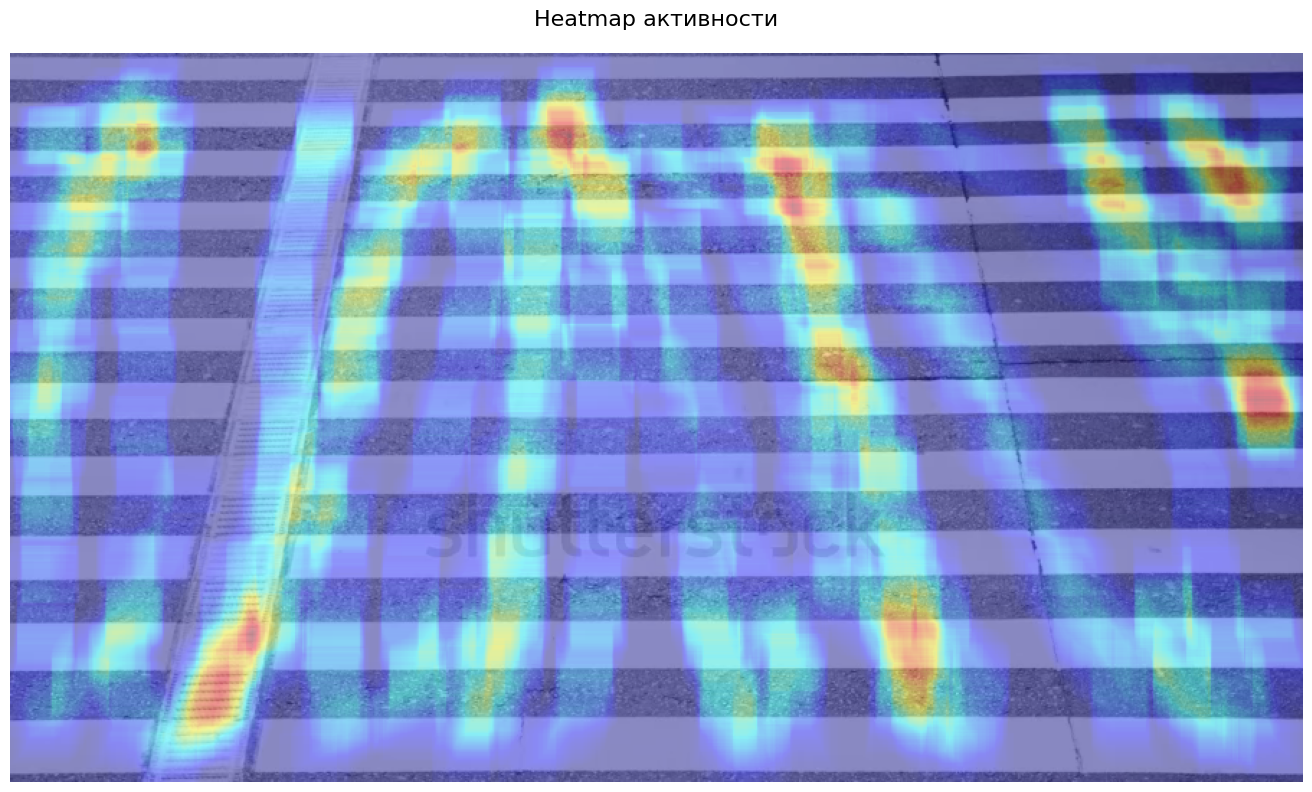

 Heatmap сохранена: heatmap.png


In [9]:
import matplotlib.pyplot as plt
# Нормализация и цвет
heatmap_norm = cv2.normalize(heatmap_accumulator, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
heatmap_color = cv2.applyColorMap(heatmap_norm, cv2.COLORMAP_JET)

# Наложение на первый кадр
cap = cv2.VideoCapture(VIDEO_PATH)
ret, frame = cap.read()
cap.release()

if ret:
    heatmap_color = cv2.resize(heatmap_color, (width, height))
    overlay = cv2.addWeighted(frame, 0.6, heatmap_color, 0.4, 0)
else:
    overlay = heatmap_color

# Сохранение файла
cv2.imwrite(OUTPUT_HEATMAP_PATH, overlay)

# 4. Красивый показ 
plt.figure(figsize=(14, 8))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Heatmap активности", fontsize=16, pad=20)
plt.axis("off")
plt.tight_layout()
plt.show()

print(f" Heatmap сохранена: {OUTPUT_HEATMAP_PATH}")